# Monthly Active Users on X

Based on: https://x.com/stats_feed/status/2036690543888228556?s=20

Note: you'll need the Awesome Font installed on your computer to properly render the old Twitter logo.

## Import

In [1]:
import matplotlib.pyplot as plt
from matplotlib import font_manager
import pandas as pd


In [2]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)


## Data

In [3]:
# The raw data structured as a dictionary
data = {
    "Year": [
        2025,
        2024,
        2023,
        2022,
        2021,
        2020,
        2019,
        2018,
        2017,
        2016,
        2015,
        2014,
        2013,
        2012,
        2011,
        2010,
    ],
    "Users_Millions": [
        611,
        600,
        450,
        401,
        396,
        353,
        330,
        321,
        330,
        318,
        305,
        288,
        241,
        185,
        117,
        54,
    ],
    "Platform": [
        "X",
        "X",
        "X",
        "Twitter",
        "Twitter",
        "Twitter",
        "Twitter",
        "Twitter",
        "Twitter",
        "Twitter",
        "Twitter",
        "Twitter",
        "Twitter",
        "Twitter",
        "Twitter",
        "Twitter",
    ],
}

df = pd.DataFrame(data)
df


,Year,Users_Millions,Platform
0,2025,611,X
1,2024,600,X
2,2023,450,X
3,2022,401,Twitter
4,2021,396,Twitter
5,2020,353,Twitter
6,2019,330,Twitter
7,2018,321,Twitter
8,2017,330,Twitter
9,2016,318,Twitter


## Add fonts

In [4]:
# Add system fonts for Matplotlib to see them
for font in font_manager.findSystemFonts(fontpaths=None, fontext="ttf"):
    font_manager.fontManager.addfont(font)


In [5]:
font_manager.get_font_names()

['DejaVu Sans Mono',
 'cmr10',
 'STIXSizeTwoSym',
 'cmb10',
 'STIXSizeFourSym',
 'cmmi10',
 'DejaVu Sans Display',
 'DejaVu Serif Display',
 'cmtt10',
 'Ubuntu Condensed',
 'STIXNonUnicode',
 'Lato',
 'FontAwesome',
 'STIXGeneral',
 'cmss10',
 'DejaVu Sans',
 'STIXSizeThreeSym',
 'cmsy10',
 'Ubuntu Mono',
 'DejaVu Serif',
 'STIXSizeOneSym',
 'Ubuntu',
 'cmex10',
 'STIXSizeFiveSym']

## Plot

### Settings

In [6]:
my_custom_grey = "#5e5c64"

plt.rcParams.update(
    {
        "font.family": "DejaVu Serif",
        "font.size": 18,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "axes.titlelocation": "left",
        "axes.titlepad": 20,
        "text.color": my_custom_grey,
        "axes.labelcolor": my_custom_grey,
        "xtick.color": my_custom_grey,
        "ytick.color": my_custom_grey,
    }
)

# This font contains Twitter logo
fa_font = font_manager.FontProperties(family="FontAwesome")

### Plotting function

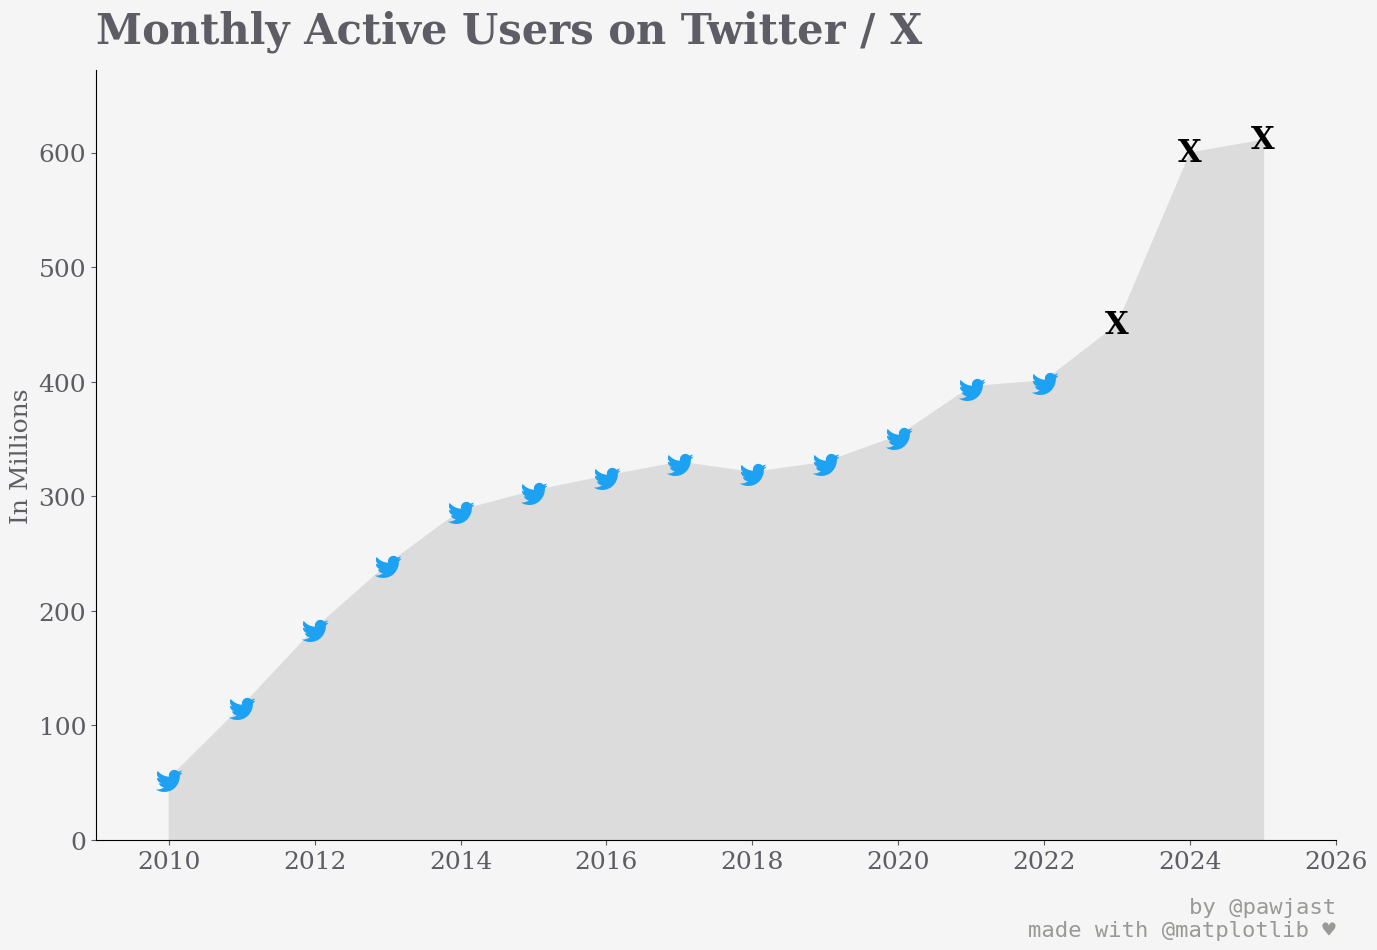

In [10]:
fig, ax = plt.subplots(figsize=(16, 10), facecolor="whitesmoke")
ax.set_facecolor("whitesmoke")

# --- DRAWING THE ICONS ---
for x, y in zip(df.Year, df.Users_Millions):
    if x < 2023:
        # Use Unicode for Twitter Bird: \uf099
        # ONLY use fa_font for THIS specific call
        ax.text(
            x,
            y,
            "\uf099",
            fontproperties=fa_font,
            fontsize=22,
            color="#1DA1F2",
            ha="center",
            va="center",
        )
    else:
        # Use Unicode for X: \ue61b (if supported) or a bold standard X
        # Standard 'X' is in DejaVu Serif, so NO fontproperties needed here!
        ax.text(
            x,
            y,
            "X",
            fontsize=22,
            color="black",
            weight="black",
            ha="center",
            va="center",
        )

ax.fill_between(
    x=df.Year,
    y1=df.Users_Millions,
    color="gainsboro"
)

# --- CLEANUP & AXES ---
ax.set_title("Monthly Active Users on Twitter / X", fontsize=30, weight="bold", loc="left", pad=20)
ax.set_ylabel("In Millions")

# Since we used ax.text, we MUST manually set limits
ax.set_xlim(df.Year.min() - 1, df.Year.max() + 1)
ax.set_ylim(0, df.Users_Millions.max() * 1.1)

# Remove spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)


# Footer
ax.text(
    1,
    -0.13,
    "by @pawjast\nmade with @matplotlib \u2665",
    transform=ax.transAxes,
    horizontalalignment="right",
    verticalalignment="bottom",
    color="#9a9996",
    fontsize=16,
    family="monospace",
    weight="medium",
);
